# **Proyecto Final Ciencia de Redes**

**Redes de Ingredientes en Recetas Regionales**

Ana Luisa Llamas Martinez

Semestre 2026-2

*Nota: Para este proyecto se han elegido las regiones Europa Occidental y Europa del Sur.*

## Construcción de la red

Para ello, se extrajeron los datos del artículo *Flavor network and the principles of food pairing*. Vamos a referirnos como nodos a los ingredientes que aparecen en las recetas; y si dos ingredientes están en una misma receta, entonces existirá un enlace entre ambos. En nuestro caso, vamos a solo considerar solo las recetas de las regiones de Europa de Occidente y de Europa del Sur, y construiremos una red para cada región.

In [148]:
import pandas as pd
import networkx as nx
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

#Creo nombres genéricos para las columnas
#La primera columna es la región y las demás son los ingredientes
nombres_columnas = ['Region'] + [f'Ingrediente_{i}' for i in range(1, 100)]

# Creación del dataset
df = pd.read_csv(
    'recetas.csv', 
    comment='#', 
    header=None, 
    names=nombres_columnas,
    sep=','
)

# Creación de un índce único para cada receta, así sabemos qué ingredientes con qué ingredientes
df['Receta_ID'] = df.index

df_long = df.melt(id_vars=['Receta_ID', 'Region'], value_name='Ingrediente')
df_long = df_long.dropna().drop(columns=['variable'])

#CONSTRUCCIÓN DE LA RED DE RECETAS DE EUROPA OCCIDENTAL
#filtración del dataset
df_western = df_long[df_long['Region'] == 'WesternEuropean']

edges_western = []
#agrupación por índice
for receta, grupo in df_western.groupby('Receta_ID'):
    ingredientes = grupo['Ingrediente'].unique()
    
    #generación de enlaces
    if len(ingredientes) > 1:
        edges_western.extend(list(combinations(ingredientes, 2)))

G1 = nx.Graph()
G1.add_edges_from(edges_western)

#CONSTRUCCIÓN DE LA RED DE RECETAS DE EUROPA DEL SUR
df_southern = df_long[df_long['Region'] == 'SouthernEuropean']

edges_southern = []
for receta, grupo in df_southern.groupby('Receta_ID'):
    ingredientes = grupo['Ingrediente'].unique()
    
    if len(ingredientes) > 1:
        edges_southern.extend(list(combinations(ingredientes, 2)))

G2 = nx.Graph()
G2.add_edges_from(edges_southern)

C:\Users\analu\AppData\Local\Temp\ipykernel_16312\3360384764.py:13: DtypeWarning: Columns (27,28,29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## Análisis de la red

**1) Descripción general de los datos**

In [149]:
#Número de recetas por región

no_recetas_western = len(df[df['Region'] == 'WesternEuropean'])
no_recetas_southern = len(df[df['Region'] == 'SouthernEuropean'])

print(f"La región de Europa Occidental tiene {no_recetas_western} recetas, mientras que Europa del Sur tiene {no_recetas_southern} recetas.")

La región de Europa Occidental tiene 2659 recetas, mientras que Europa del Sur tiene 4180 recetas.


In [150]:
#Número de ingredientes distintos

print(f"Hay {G1.number_of_nodes()} ingredientes distintos en las recetas de Europa Occidental, mientras que en la Europa del Sur hay {G2.number_of_nodes()}.")

Hay 308 ingredientes distintos en las recetas de Europa Occidental, mientras que en la Europa del Sur hay 290.


In [151]:
# Tamaño promedio de las recetas.

#Europa Occidental
df_western = df[df['Region'] == 'WesternEuropean']
promedio_ingredientes_western = df_western.notna().sum(axis=1).mean()

#Europa Occidental
df_southern = df[df['Region'] == 'SouthernEuropean']
promedio_ingredientes_southern = df_southern.notna().sum(axis=1).mean()

print(f"El tamaño promedio de ingredientes en la región de Europa Occidental es de {promedio_ingredientes_western}. En cambio, en Europa del Sur es de {promedio_ingredientes_southern}")

El tamaño promedio de ingredientes en la región de Europa Occidental es de 10.025949605114704. En cambio, en Europa del Sur es de 10.860765550239234


In [152]:
# Ingredientes más frecuentes por región
#df_western.stack().value_counts()
ingredientes_frecuencia_western = df_western.drop(columns=['Region', 'Receta_ID'], errors='ignore').stack().value_counts()
ingredientes_frecuencia_southern = df_southern.drop(columns=['Region', 'Receta_ID'], errors='ignore').stack().value_counts()

print("     Europa Occidental")
print(ingredientes_frecuencia_western.head(5))

print("     Europa del Sur")
print(ingredientes_frecuencia_southern.head(5))

     Europa Occidental
butter    1395
egg       1303
wheat     1278
onion      720
milk       693
Name: count, dtype: int64
     Europa del Sur
olive_oil    2612
garlic       2181
tomato       1593
onion        1451
egg          1097
Name: count, dtype: int64


**Resumen:**

En la región de Europa Occidental se encontraron 2659 recetas constituidas por 308 ingredientes diferentes, teniendo un promedio de 10 ingredientes por receta. En cambio, en la región del Sur hay 4180 recetas a partir de 290 ingredientes y, por receta, hay en promedio 11 ingredientes.

La mantequilla, el huevo, el trigo, la cebolla y la leche son los ingredientes más comunes en la dieta de Europa Occidental; en cambio, en el Sur son el aceite de oliva, el ajo, el jitomate, la cebolla y el huevo. 


**2) Propiedades básicas de las redes**

In [153]:
# Número de nodos y aristas.
nodosg1 = G1.number_of_nodes()
aristasg1 = G1.number_of_edges()
nodosg2 = G2.number_of_nodes()
aristasg2 = G2.number_of_edges()

# Densidad
densidadg1 = nx.density(G1)
densidadg2 = nx.density(G2)

# Componente conexas
componentesg1 = list(nx.connected_components(G1))
componentesg2 = list(nx.connected_components(G2))

# Componente gigante
componente_gigante_g1 = max(nx.connected_components(G1), key=len)
componente_gigante_g2 = max(nx.connected_components(G2), key=len)

# Grado promedio
grado_promediog1 = (2 * aristasg1) / nodosg1
grado_promediog2 = (2 * aristasg2) / nodosg2

#Coeficiente de clustering
clust_promg1 = nx.average_clustering(G1)
clust_promg2 = nx.average_clustering(G2)

#Distancia promedio
dist_promg1 = nx.average_shortest_path_length(G1)
dist_promg2 = nx.average_shortest_path_length(G2)

#Diámetro de la red
diametrog1 = nx.diameter(G1)
diametrog2 = nx.diameter(G2)

#Creación de tabla con las propiedades anteriores
data_propiedades = {"Propiedad": ["No. de nodos", "No. de aristas", "Densidad", "No. de componentes conexas", "Tamaño de la componente conexa", "Grado promedio", "Coef. de clustering", "Distancia promedio", "Diametro de la red"],
                    "Europa del Occidente": [nodosg1, aristasg1, densidadg1, len(componentesg1), len(componente_gigante_g1), grado_promediog1, clust_promg1, dist_promg1, diametrog1],
                    "Europa del Sur": [nodosg2, aristasg2, densidadg2, len(componentesg2), len(componente_gigante_g2), grado_promediog2, clust_promg2, dist_promg2, diametrog2]

}

propiedades_df = pd.DataFrame(data_propiedades)

print(propiedades_df)

                        Propiedad  Europa del Occidente  Europa del Sur
0                    No. de nodos            308.000000      290.000000
1                  No. de aristas          12041.000000    12181.000000
2                        Densidad              0.254685        0.290681
3      No. de componentes conexas              1.000000        1.000000
4  Tamaño de la componente conexa            308.000000      290.000000
5                  Grado promedio             78.188312       84.006897
6             Coef. de clustering              0.758316        0.783458
7              Distancia promedio              1.769005        1.726262
8              Diametro de la red              3.000000        3.000000


In [154]:
#Distribución de grado

lista_gradosg1 = dict(G1.degree())
lista_gradosg2 = dict(G2.degree())

coef_gradosg1 = list(lista_gradosg1.values())
coef_gradosg2 = list(lista_gradosg2.values())

frecuenciag1 = Counter(coef_gradosg1)
frecuenciag2 = Counter(coef_gradosg2)

X1 = sorted(frecuenciag1.keys())
X2 = sorted(frecuenciag2.keys())

Y1 = [frecuenciag1[k] / nodosg1 for k in X1]
Y2 = [frecuenciag2[k] / nodosg2 for k in X2]

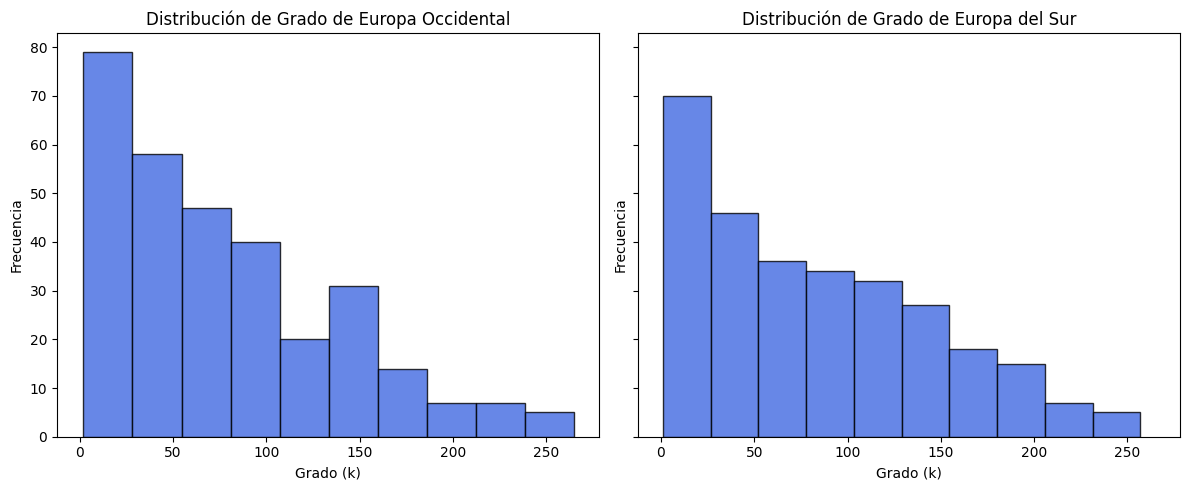

In [155]:
#Creación de gráficas
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axs[0].hist(coef_gradosg1, bins=10, color='royalblue', edgecolor='black', alpha=0.8)
axs[0].set_title('Distribución de Grado de Europa Occidental', fontsize=12)
axs[0].set_xlabel('Grado (k)', fontsize=10)
axs[0].set_ylabel('Frecuencia', fontsize=10)

axs[1].hist(coef_gradosg2, bins=10, color='royalblue', edgecolor='black', alpha=0.8)
axs[1].set_title('Distribución de Grado de Europa del Sur', fontsize=12)
axs[1].set_xlabel('Grado (k)', fontsize=10)
axs[1].set_ylabel('Frecuencia', fontsize=10)

plt.tight_layout()
plt.show()

**Resumen:**

Como se mencionó anteriormente, En Europa Occidental hay 308 ingredientes, por lo tanto, su red contiene esa misma cantidad de nodos. Por otra parte, dicha red tiene 12041 aristas; a pesar de ser un número bastante grande, solo representa aproximadamente el 25% de todas las conexiones posibles entre pares de nodos, lo que podemos interpretar como que las recetas no tienen mucha variedad. Luego, se reportó un grado promedio de 78.18, así que podemos decir que en promedio un ingrediente se combina con otros 78 ingredientes diferentes. De igual forma, el coeficiente de clustering de esta red es de 0.75, lo que nos dice que es muy probable que dos ingredientes sean combinados si ya han sido mezclados con otro mismo ingrediente. Por último, también concluimos que la red es altamente conexa, dado que la distancia promedio es de 1.77 y el diámetro, 3; además que la red contiene una sola única componente conexa, la cual contiene a todos sus nodos.

Ahora, enfocándonos en la red construida a partir de los datos de la región del Sur, tenemos 290 nodos y y 12181 aristas. Al igual que la red anterior, sus recetas no varian mucho en ingredientes, dado que su densidad es de aproximadamente 30%. Por otra parte, el grado promedio es de 84.00, así que en promedio un ingrediente se combina con otros 84 ingredientes diferentes; es muy probable que estos vecinos también se enlacen entre ellos porque el coeficiente de clustering es de 0.78. Finalmente, también concluimos que es una red muy conexa, puesto que distancia promedio es de 1.72 y el diámetro es de 3; de igual forma, la red contiene una sola única componente conexa.

Ahora, hablando sobre la distribución de grado, observamos que en ambas gráficas existe un sesgo hacia la izquierda, además de tener colas pesadas. Ésto significa que en ambas regiones, la inmensa mayoría de los ingredientes tienen un grado muy bajo, en otras palabras, no se combinan muy seguido. Por el contrario, tambiéne existen, aunque en menor cantidad, ingredientes que actúan como hubs. Lo que nos podría dar un indicio de qué ingredientes son la base de la dieta en estas regiones.

**3) Centralidades**

In [156]:
#Europa Occidental
#Calculo de centralidades
cent_gradog1 = dict(nx.degree_centrality(G1))
cent_interg1 = dict(nx.betweenness_centrality(G1))
cent_cercg1 = dict(nx.closeness_centrality(G1))

cent_gradog1_ord = sorted(cent_gradog1, key=cent_gradog1.get, reverse=True)[0:10]
cent_interg1_ord = sorted(cent_interg1, key=cent_interg1.get, reverse=True)[0:10]
cent_cercg1_ord = sorted(cent_cercg1, key=cent_cercg1.get, reverse=True)[0:10]

#creación de tabla con los datos
ingredientes_importg1 = {'Grado': cent_gradog1_ord, 'Intermediación': cent_interg1_ord, 'Cercanía': cent_cercg1_ord}

ingredientes_importg1_df = pd.DataFrame(ingredientes_importg1)

print("                 Europa Occidental")
print(ingredientes_importg1_df)

                 Europa Occidental
           Grado Intermediación       Cercanía
0            egg            egg            egg
1         butter         butter         butter
2          wheat          wheat          wheat
3          onion          cream          onion
4   black_pepper          onion   black_pepper
5          cream   black_pepper          cream
6           milk      olive_oil           milk
7      olive_oil           milk      olive_oil
8  vegetable_oil         garlic  vegetable_oil
9          bread          bread          bread


In [157]:
#Europa del Sur
#Calculo de centralidades
cent_gradog2 = dict(nx.degree_centrality(G2))
cent_interg2 = dict(nx.betweenness_centrality(G2))
cent_cercg2 = dict(nx.closeness_centrality(G2))

cent_gradog2_ord = sorted(cent_gradog2, key=cent_gradog2.get, reverse=True)[0:10]
cent_interg2_ord = sorted(cent_interg2, key=cent_interg2.get, reverse=True)[0:10]
cent_cercg2_ord = sorted(cent_cercg2, key=cent_cercg2.get, reverse=True)[0:10]

#creación de tabla con los datos
ingredientes_importg2 = {'Grado': cent_gradog2_ord, 'Intermediación': cent_interg2_ord, 'Cercanía': cent_cercg2_ord}

ingredientes_importg2_df = pd.DataFrame(ingredientes_importg2)

print("                 Europa del Sur")
print(ingredientes_importg2_df)

                 Europa del Sur
          Grado Intermediación      Cercanía
0     olive_oil      olive_oil     olive_oil
1        garlic         butter        garlic
2        butter         garlic        butter
3         onion            egg         onion
4  black_pepper   black_pepper  black_pepper
5           egg          cream           egg
6       parsley          onion       parsley
7        tomato        parsley        tomato
8         cream          wheat         cream
9        cheese         tomato        cheese


In [158]:
#elementos en común según la centralidad
conj_cent_gradog1 = set(cent_gradog1_ord)
conj_cent_gradog2 = set(cent_gradog2_ord)

conj_cent_interg1 = set(cent_interg1_ord)
conj_cent_interg2 = set(cent_interg2_ord)

conj_cent_cercg1 = set(cent_cercg1_ord)
conj_cent_cercg2 = set(cent_cercg2_ord)


interseccion_cent_grado = conj_cent_gradog1.intersection(conj_cent_gradog2)
interseccion_cent_inter = conj_cent_interg1.intersection(conj_cent_interg2)
interseccion_cent_cerc = conj_cent_cercg1.intersection(conj_cent_cercg2)

print("Por centralidad de grado, la región de Occidente y la del Sur tienen en común estos ingredientes:", interseccion_cent_grado)
print("Por centralidad de intermediación, la región de Occidente y la del Sur tienen en común estos ingredientes:", interseccion_cent_inter)
print("Por centralidad de cercanía, la región de Occidente y la del Sur tienen en común estos ingredientes:", interseccion_cent_cerc)

Por centralidad de grado, la región de Occidente y la del Sur tienen en común estos ingredientes: {'egg', 'black_pepper', 'olive_oil', 'cream', 'onion', 'butter'}
Por centralidad de intermediación, la región de Occidente y la del Sur tienen en común estos ingredientes: {'egg', 'black_pepper', 'wheat', 'olive_oil', 'garlic', 'cream', 'onion', 'butter'}
Por centralidad de cercanía, la región de Occidente y la del Sur tienen en común estos ingredientes: {'egg', 'black_pepper', 'olive_oil', 'cream', 'onion', 'butter'}


**Resumen:**

En la red de Europa Occidental se observa que el huevo, la mantequilla y el trigo encabezan las listas de las tres métricas. Ésto refleja que no solo se combinan con una cantidad masiva de otros ingredientes, sino que además se encuentran a una distancia mínima de cualquier otro elemento en la red. Son la base de la mayoría de recetas. Este mismo efecto se puede apreciar en la red de Europa del Sur, pero con el aceite de oliva, la mantequilla y el ajo.

También cabe destacar que también la pimienta negra, la crema y la cebolla aparecen en los podios de ambas regiones.


**4) Comunidades**

In [159]:
#Detección de comunidades en la red

comunidades_louvaing1 = nx.community.louvain_communities(G1, seed = 777)
comunidades_louvaing2 = nx.community.louvain_communities(G2, seed = 777)

print(f"Se detectaron {len(comunidades_louvaing1)} comunidades en la red de Europa Occidental, mientras que en la red de Europa del Sur hay {len(comunidades_louvaing2)} comunidades.")

Se detectaron 4 comunidades en la red de Europa Occidental, mientras que en la red de Europa del Sur hay 3 comunidades.


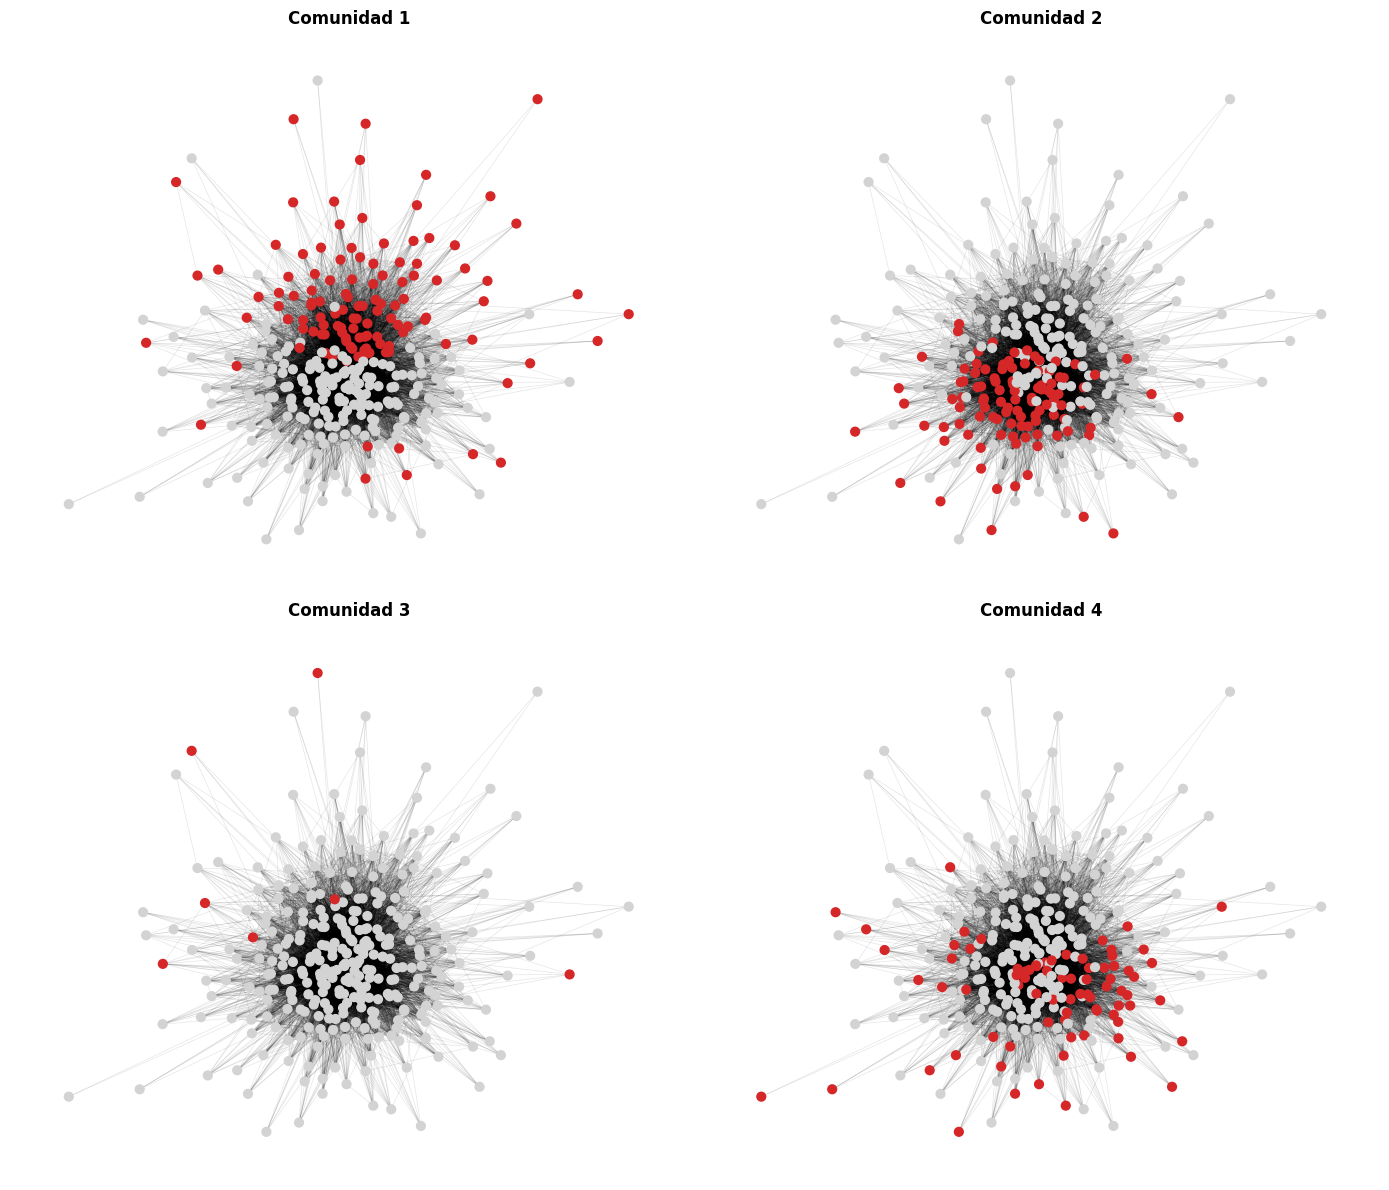

In [160]:
#Visualización de las comunidades

#Europa Occidental
posg1 = nx.spring_layout(G1, seed=27)

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs_flat = axs.flatten()

titulos_g1 = [
    "Comunidad 1",
    "Comunidad 2",
    "Comunidad 3",
    "Comunidad 4"
]

for i, ax in enumerate(axs_flat):
    comunidad_actual = set(comunidades_louvaing1[i])
    
    color_map = ["tab:red" if n in comunidad_actual else "lightgray" for n in G1.nodes()]
    
    nx.draw_networkx_nodes(G1, posg1, ax=ax, node_color=color_map, node_size=40)

    nx.draw_networkx_edges(G1, posg1, ax=ax, width=0.5, alpha=0.1)

    ax.set_title(titulos_g1[i], fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

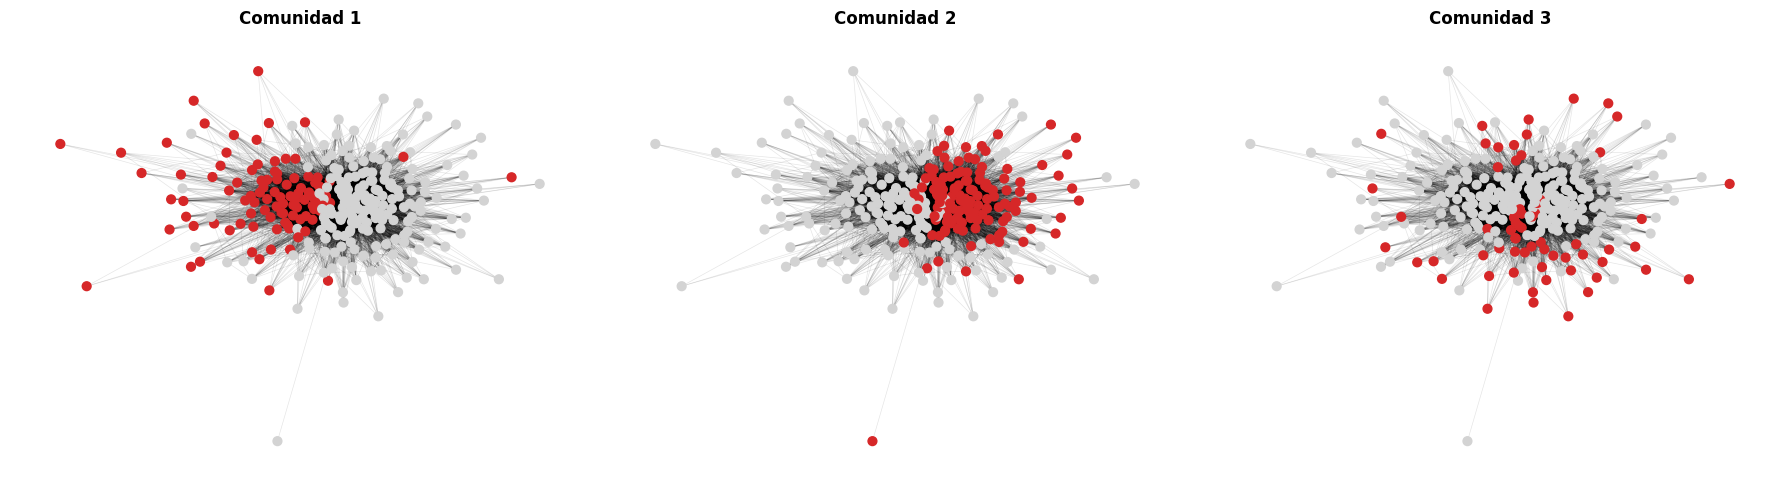

In [161]:
#Europa Occidental

posg2 = nx.spring_layout(G2, seed=27)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs_flat = axs.flatten()

titulos_g2 = [
    "Comunidad 1",
    "Comunidad 2",
    "Comunidad 3"
]

for i, ax in enumerate(axs_flat):
    comunidad_actual = set(comunidades_louvaing2[i])
    
    color_map = ["tab:red" if n in comunidad_actual else "lightgray" for n in G2.nodes()]
    
    nx.draw_networkx_nodes(G2, posg2, ax=ax, node_color=color_map, node_size=40)

    nx.draw_networkx_edges(G2, posg2, ax=ax, width=0.5, alpha=0.1)

    ax.set_title(titulos_g2[i], fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [162]:
#Modularidad de la red

modularidadg1 = nx.community.modularity(G1, comunidades_louvaing1)
modularidadg2 = nx.community.modularity(G2, comunidades_louvaing2)

print(f"La modularidad de la red de Europa Occidental es {modularidadg1}, mientras que la modularidad de la red de Europa del Sur es {modularidadg2}.")

La modularidad de la red de Europa Occidental es 0.12501253485852853, mientras que la modularidad de la red de Europa del Sur es 0.10989723316577851.


In [163]:
# Interpretación de los grupos encontrados en las redes y comparación de las comunidades entre las regiones

#Europa Occidental
top_ingredientes_g1 = []
for i, comun in enumerate(comunidades_louvaing1):
    grados_comunidad = {ingrediente: lista_gradosg1[ingrediente] for ingrediente in comun}
    
    top = sorted(grados_comunidad, key=grados_comunidad.get, reverse=True)[:10]
    top_ingredientes_g1.append(top)

top_ingredientesg1_data = {'Comunidad 1': pd.Series(top_ingredientes_g1[0]), 'Comunidad 2': pd.Series(top_ingredientes_g1[1]), 'Comunidad 3': pd.Series(top_ingredientes_g1[2]), 'Comunidad 4': pd.Series(top_ingredientes_g1[3])}

top_ingredientesg1_df = pd.DataFrame(top_ingredientesg1_data)

print(top_ingredientesg1_df)


     Comunidad 1 Comunidad 2   Comunidad 3   Comunidad 4
0            egg     vinegar    lime_juice         onion
1         butter      tomato         mango  black_pepper
2          wheat      pepper        papaya     olive_oil
3          cream      carrot       octopus         bread
4           milk  white_wine         melon        garlic
5  vegetable_oil      potato  jamaican_rum       parsley
6    lemon_juice      cheese        litchi         thyme
7          lemon      ginger           NaN       mustard
8  cane_molasses      celery           NaN           bay
9          apple       chive           NaN          beef


In [164]:
#Europa del Sur
top_ingredientes_g2 = []
for i, comun in enumerate(comunidades_louvaing2):
    grados_comunidad = {ingrediente: lista_gradosg2[ingrediente] for ingrediente in comun}
    
    top = sorted(grados_comunidad, key=grados_comunidad.get, reverse=True)[:10]
    top_ingredientes_g2.append(top)

top_ingredientesg2_data = {'Comunidad 1': pd.Series(top_ingredientes_g2[0]), 'Comunidad 2': pd.Series(top_ingredientes_g2[1]), 'Comunidad 3': pd.Series(top_ingredientes_g2[2])}

top_ingredientesg2_df = pd.DataFrame(top_ingredientesg2_data)

print(top_ingredientesg2_df)

     Comunidad 1      Comunidad 2   Comunidad 3
0         butter            onion     olive_oil
1            egg           tomato        garlic
2          cream          vinegar  black_pepper
3         cheese            basil       parsley
4          wheat      bell_pepper    white_wine
5    lemon_juice           pepper       cayenne
6  vegetable_oil  parmesan_cheese         olive
7           milk            bread          fish
8          lemon    chicken_broth         cumin
9         orange            thyme        shrimp


**Resumen:**

Primero, identificamos las cuatro comunidades en la red de Europa Occidental. En el primer grupo resalta el huevo, la mantequilla, el trigo, la crema, la leche, el aceite vegetal, el jugo de limón, el limón, la melaza de caña y la manzana; esta variedad tiene una tendencia dulce y un poco ácida/agria, como la repostería. En el segundo grupo está el vinagre, el jitomate, la pimienta, la zanahoria, el vino blanco, la papa, el queso, el gengibre, el apio y el cebollino; ingredientes base para salsas y/o sopas. En el tercer grupo hay jugo de lima, mango, papaya, pulpo, melon, ron de jamaica y lichi; ingredientes que en conjunto suena como un disparate, pero que podrían ser de recetas de algún platillo muy específico de una zona de la región. Finalmente, el cuarto grupo contiene a la cebolla, a la pimienta negra, aceite de oliva, pan, ajo, el peregil, el tomillo, la mostaza, hojas de laurel y carne de res; podemos apreciar que la mayoría son condimentos para sazonar plato fuertes.

En el caso de la red de Europa del Sur, solo hay tres comunidades. En la primera resalta la mantequilla, el huevo, la crema, el queso, el trigo, el jugo de limón, el aceite vegetal, la leche, el limón y la naranja; bastante parecido al primer grupo de la red anterior. En el segundo grupo hay cebolla, jitomate, vinagre, albahaca, pimiento morrón, pimienta, queso parmesano, pan, pechuga de pollo y el tomillo; como un conjunto típico para caldos. Por último, en el último grupo existe el aceite de oliva, el ajo, la pimienta negra, el perejil, el vino blanco, el pimentón, la aceituna, el pescado, el comino y el camarón.

Podemos apreciar que éstos grupos son diversos, incluso dentro de ellos mismos. Ésto podría ser a raíz de que la modularidad en ambas gráficas es muy baja, por ende, no hay muchas combinaciones entre ingredientes del mismo grupo.

**5) Comparación entre regiones**

In [165]:
# Ingredientes compartidos entre ambas regiones

conj_nodosg1 = set(G1.nodes())
conj_nodosg2 = set(G2.nodes())

interseccion = conj_nodosg1.intersection(conj_nodosg2)

print(f"Las regiones de Europa Occidental y del Sur comparten {len(interseccion)} ingredientes entre sus recetas. Por ejemplo, están {list(interseccion)[:10]}")

Las regiones de Europa Occidental y del Sur comparten 267 ingredientes entre sus recetas. Por ejemplo, están ['cereal', 'egg', 'soy_sauce', 'cream_cheese', 'bell_pepper', 'watercress', 'berry', 'celery_oil', 'scallion', 'mango']


In [166]:
#Ingredientes característicos de cada región

exclusivos_g1 = conj_nodosg1 - conj_nodosg2
exclusivos_g2 = conj_nodosg2 - conj_nodosg1

print(f"Europa Occidental tiene {len(exclusivos_g1)} ingredientes característicos, por ejemplo {list(exclusivos_g1)[0:3]}. Mientras que Europa del Sur son {len(exclusivos_g2)} ingredientes, entre ellos, {list(exclusivos_g2)[0:3]}.")

Europa Occidental tiene 41 ingredientes característicos, por ejemplo ['bergamot', 'elderberry', 'hop']. Mientras que Europa del Sur son 23 ingredientes, entre ellos, ['lime_peel_oil', 'cassava', 'yam'].


In [178]:
#parejas más frecuentes

#Europa Occidente

df_limpio_w = df_western.drop(columns=['Region', 'Receta_ID'], errors='ignore')
recetas_sets_w = [set(row) for row in df_limpio_w.values if isinstance(row, np.ndarray)] # Convierto cada receta en un set para que las búsquedas con el operador in sean mucho más rápidas

parejas_frecuenciag1 = []
# Recorro cada enlace (arista) existente en el grafo
for u, v in G1.edges():
    # Cuento en cuántas recetas aparecen juntos el ingrediente u y el ingrediente v
    frecuencia = sum(1 for receta in recetas_sets_w if u in receta and v in receta)
    parejas_frecuenciag1.append(((u, v), frecuencia))

top_5_w = sorted(parejas_frecuenciag1, key=lambda x: x[1], reverse=True)[:5]

print("Europa Occidental")
print(top_5_w)

Europa Occidental
[(('butter', 'wheat'), 947), (('wheat', 'egg'), 932), (('butter', 'egg'), 817), (('milk', 'egg'), 509), (('wheat', 'milk'), 503)]


In [168]:
#Europa del Sur
df_limpio_s = df_southern.drop(columns=['Region', 'Receta_ID'], errors='ignore')
recetas_sets_s = [set(row) for row in df_limpio_s.values if isinstance(row, np.ndarray)]

parejas_frecuenciag2 = []
for u, v in G2.edges():
    frecuencia = sum(1 for receta in recetas_sets_s if u in receta and v in receta)
    parejas_frecuenciag2.append(((u, v), frecuencia))

top_5_s = sorted(parejas_frecuenciag2, key=lambda x: x[1], reverse=True)[:5]

print("Europa del Sur")
print(top_5_s)

Europa del Sur
[(('olive_oil', 'garlic'), 1760), (('tomato', 'olive_oil'), 1250), (('tomato', 'garlic'), 1196), (('olive_oil', 'onion'), 1063), (('onion', 'garlic'), 962)]


In [169]:
#Diferencias en estructura
print(propiedades_df)

                        Propiedad  Europa del Occidente  Europa del Sur
0                    No. de nodos            308.000000      290.000000
1                  No. de aristas          12041.000000    12181.000000
2                        Densidad              0.254685        0.290681
3      No. de componentes conexas              1.000000        1.000000
4  Tamaño de la componente conexa            308.000000      290.000000
5                  Grado promedio             78.188312       84.006897
6             Coef. de clustering              0.758316        0.783458
7              Distancia promedio              1.769005        1.726262
8              Diametro de la red              3.000000        3.000000


In [170]:
print("      Centralidades de Europa Occidental")
print(ingredientes_importg1_df)

      Centralidades de Europa Occidental
           Grado Intermediación       Cercanía
0            egg            egg            egg
1         butter         butter         butter
2          wheat          wheat          wheat
3          onion          cream          onion
4   black_pepper          onion   black_pepper
5          cream   black_pepper          cream
6           milk      olive_oil           milk
7      olive_oil           milk      olive_oil
8  vegetable_oil         garlic  vegetable_oil
9          bread          bread          bread


In [171]:
print("      Centralidades de Europa del Sur")
print(ingredientes_importg2_df)

      Centralidades de Europa del Sur
          Grado Intermediación      Cercanía
0     olive_oil      olive_oil     olive_oil
1        garlic         butter        garlic
2        butter         garlic        butter
3         onion            egg         onion
4  black_pepper   black_pepper  black_pepper
5           egg          cream           egg
6       parsley          onion       parsley
7        tomato        parsley        tomato
8         cream          wheat         cream
9        cheese         tomato        cheese


**Resumen:**

Las regiones de Europa Occidental y del Sur comparten 267 ingredientes entre sus recetas. Por ejemplo, están el cereal, el huevo, la salsa de soya, el queso crema, el pimiento morrón, el berro, las bayas, el aceite de apio, el cebollino y el mango. No obstante, también tienen ingredientes característicos; en Europa Occidental está el aceite de bergamota, la baya de saúco y conos de hop. En cambio, Europa del Sur tiene aceite de cáscara de lima, yuca y ñame.

Por otra parte, las combinaciones de ingredientes más populares en Europa Occidental son mantequilla y trigo, trigo y huevo, mantequilla y huevo, leche y huevo, y trigo y leche. En el caso de Europa del Sur, son aceite de oliva y ajo, jitomate y aceite de oliva, jitomate y ajo, aceite de oliva y cebolla, y cebolla y ajo.

**6) Comparación con modelos aleatorios**

In [172]:
# Comparar cada red real con una red aleatoria

#Europa Occidental
p1 = grado_promediog1/ (nodosg1 - 1)
k1 = int(round(grado_promediog1))
m1 = max(1, int(round(aristasg1 / nodosg1)))

ERg1 = nx.erdos_renyi_graph(nodosg1, p1, seed=777)
WSg1 = nx.watts_strogatz_graph(nodosg1, k1, 0.1, seed=777)
BAg1 = nx.barabasi_albert_graph(nodosg1, m1, seed=777)

redesg1 = [ERg1, WSg1, BAg1]
coef_clust_listag1 = [clust_promg1]
long_media_listag1 = [nx.average_shortest_path_length(G1)]

for i in range(0,3):
    if nx.is_connected(redesg1[i])  is True:
        long = nx.average_shortest_path_length(redesg1[i])
        long_media_listag1.append(long)
    elif nx.is_connected(redesg1[i])  is False:
        componentes = sorted(nx.connected_components(redesg1[i]), key=len, reverse=True)
        comp_conexa_g = componentes[0]

        G_comp_conexa_g = redesg1[i].subgraph(comp_conexa_g).copy()

        long = nx.average_shortest_path_length(G_comp_conexa_g)
        long_media_listag1.append(long)
    
    clust = nx.average_clustering(redesg1[i])
    coef_clust_listag1.append(clust)

In [173]:
#Europa del Sur
p2 = grado_promediog2/ (nodosg2 - 1)
k2 = int(round(grado_promediog2))
m2 = max(1, int(round(aristasg2 / nodosg2)))

ERg2 = nx.erdos_renyi_graph(nodosg2, p2, seed=777)
WSg2 = nx.watts_strogatz_graph(nodosg2, k2, 0.1, seed=777)
BAg2 = nx.barabasi_albert_graph(nodosg2, m2, seed=777)

redesg2 = [ERg2, WSg2, BAg2]
coef_clust_listag2 = [clust_promg2]
long_media_listag2 = [nx.average_shortest_path_length(G2)]

for i in range(0,3):
    if nx.is_connected(redesg2[i])  is True:
        long = nx.average_shortest_path_length(redesg2[i])
        long_media_listag2.append(long)
    elif nx.is_connected(redesg2[i])  is False:
        componentes = sorted(nx.connected_components(redesg2[i]), key=len, reverse=True)
        comp_conexa_g = componentes[0]

        G_comp_conexa_g = redesg2[i].subgraph(comp_conexa_g).copy()

        long = nx.average_shortest_path_length(G_comp_conexa_g)
        long_media_listag2.append(long)
    
    clust = nx.average_clustering(redesg2[i])
    coef_clust_listag2.append(clust)

In [174]:
data_aleatorias_western = {'Coeficiente de clustering' : coef_clust_listag1, 'Longitud media de caminos': long_media_listag1}

data_aleatorias_western_df = pd.DataFrame(data_aleatorias_western)

print("                 Europa Occidental")
print(data_aleatorias_western_df)

                 Europa Occidental
   Coeficiente de clustering  Longitud media de caminos
0                   0.758316                   1.769005
1                   0.252979                   1.746309
2                   0.575871                   1.749038
3                   0.315328                   1.778100


In [175]:
data_aleatorias_southern = {'Coeficiente de clustering' : coef_clust_listag2, 'Longitud media de caminos': long_media_listag2}

data_aleatorias_southern_df = pd.DataFrame(data_aleatorias_southern)

print("                 Europa del Sur")
print(data_aleatorias_southern_df)

                 Europa del Sur
   Coeficiente de clustering  Longitud media de caminos
0                   0.783458                   1.726262
1                   0.289765                   1.709653
2                   0.579672                   1.709796
3                   0.342245                   1.751438


C:\Users\analu\AppData\Local\Temp\ipykernel_16312\568674012.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\analu\AppData\Local\Temp\ipykernel_16312\568674012.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


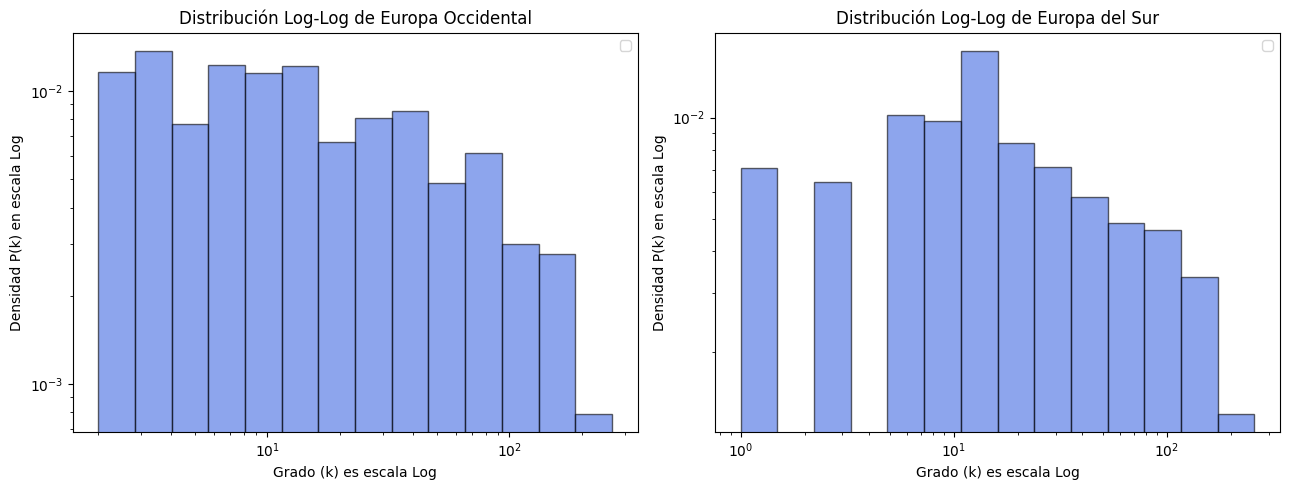

In [176]:
# efecto de libre escala

plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)

bines1 = np.logspace(np.log10(min(coef_gradosg1)), np.log10(max(coef_gradosg1)), num=15)

plt.hist(coef_gradosg1, bins=bines1, density=True, color="royalblue", alpha=0.6, edgecolor='k')
plt.xscale('log')
plt.yscale('log')
plt.title("Distribución Log-Log de Europa Occidental", fontsize=12)
plt.xlabel("Grado (k) es escala Log", fontsize=10)
plt.ylabel("Densidad P(k) en escala Log", fontsize=10)
plt.legend()

plt.subplot(1, 2, 2)

bines2 = np.logspace(np.log10(min(coef_gradosg2)), np.log10(max(coef_gradosg2)), num=15)

plt.hist(coef_gradosg2, bins=bines2, density=True, color="royalblue", alpha=0.6, edgecolor='k')
plt.xscale('log')
plt.yscale('log')
plt.title("Distribución Log-Log de Europa del Sur", fontsize=12)
plt.xlabel("Grado (k) es escala Log", fontsize=10)
plt.ylabel("Densidad P(k) en escala Log", fontsize=10)
plt.legend()

plt.tight_layout()
plt.show()

**Resumen:**

Las redes de ambas regiones muestran un coeficiente de clustering muy superior (0.75 y 0.78) en comparación con sus equivalentes de Erdős-Rényi (0.25 y 0.28). A pesar de que las longitudes medias se parecen en ambos casos, el bajo coeficiente de clustering de los modelos Erdős-Rényi nos hace rechazar la hipótesis de estructuras aleatorias, es decir, las recetas de estas dos regiones no fueron combinaciones al azar, siguen alguna tendencia de sabores y/o cultura.

Luego, el modelo de Watts-Strogatz es el que más se asemeja a nuestras redes reales. Teniendo una distancia de caminos cortos de aproximadamente 1.7 todos, seguido de un coeficiente clustering considerable (en el caso de nuestras redes reales, alto). Por lo tanto, podemos aceptar la propiedad de mundo pequeño en nuestras redes de Europa Occidental y Europa del Sur. En otras palabras, los ingredientes están altamente conectados por vecindades, no obstante, no es necesario recorrer varias combinaciones para conectar dos ingredientes.

Finalmente, observando los resultados de los modelos de Barabási-Albert y los dos histogramas (las cuales presentan mesetas y decaimiento de las colas), se rechaza la idea de que las redes presenten el efecto de libre escala.